# 12yr RecallOverride recovery and fitting

In the RecallOverride model, recall acts more globally than in the NoInhibition model.

The predicted accuracy has the form

$$
P(\text{correct}) =
p_{\text{recall}} \, P(\text{correct}\mid \text{recall})
+
(1-p_{\text{recall}})
\Big[
p_{\text{intention}} \, P(\text{correct}\mid \text{proactive})
+
(1-p_{\text{intention}})\, P(\text{correct}\mid \text{habit})
\Big].
$$

So:

- $p_{\text{recall}}$ controls how often behavior is governed by the recall pathway,
- $p_{\text{intention}}$ only acts inside the remaining non-recall branch.

Evaluate **2-parameter RecallOverride measurement model** for the 12-year AX-CPT fitting sample:

1. define the 2-parameter RecallOverride measurement model,
2. run simulation-based recovery using the **real filtered denominators**,
3. summarize recovery quality with:
   - true vs recovered scatterplots,
   - correlation,
   - bias,
   - RMSE,
   - boundary-collapse rates,
4. fit the real retained sample if recovery is acceptable,
5. compare observed vs predicted AX / AY / BX / BY accuracies.

This notebook treats RecallOverride as a **targeted structural follow-up** to the 2-parameter NoInhibition model.

## Setup

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import binom

In [8]:
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

fit_path = project_root / "data" / "AXCPT_12yr_fitting_sample.csv"

print("Project root:", project_root)
print("Fitting file:", fit_path)
print("Exists:", fit_path.exists())

fit_df = pd.read_csv(fit_path)

print("Loaded:", fit_path)
print("Shape:", fit_df.shape)

Project root: /Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition
Fitting file: /Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition/data/AXCPT_12yr_fitting_sample.csv
Exists: True
Loaded: /Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition/data/AXCPT_12yr_fitting_sample.csv
Shape: (129, 41)


### Define trial-type columns and fixed settings

In [9]:
TRIAL_TYPES = ["AX", "AY", "BX", "BY"]

count_cols = [
    "AX_Count_Filtered_12yr",
    "AY_Count_Filtered_12yr",
    "BX_Count_Filtered_12yr",
    "BY_Count_Filtered_12yr",
]

acc_count_cols = [
    "AX_Acc_Count_12yr",
    "AY_Acc_Count_12yr",
    "BX_Acc_Count_12yr",
    "BY_Acc_Count_12yr",
]

acc_rate_cols = [
    "AX_Acc_12yr",
    "AY_Acc_12yr",
    "BX_Acc_12yr",
    "BY_Acc_12yr",
]

p_cue_probe = np.array([0.70, 0.10, 0.10, 0.10], dtype=float)

load = 1
m = 1.0
p_slip = 1 - fit_df["BY_Acc_12yr"].mean()   # sample-specific slip estimate
lambda_ = 0.0

print("Using p_cue_probe =", p_cue_probe)
print("Using load =", load)
print("Using m =", m)
print("Using p_slip =", p_slip)
print("Using lambda_ =", lambda_)

Using p_cue_probe = [0.7 0.1 0.1 0.1]
Using load = 1
Using m = 1.0
Using p_slip = 0.15375528863900956
Using lambda_ = 0.0


### Component accuracies (shared across measurement models)

- habitual accuracy,
- proactive accuracy,
- recall accuracy.

In [10]:
def compute_component_accuracies(p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    """
    Returns habit, proactive, and recall accuracies for [AX, AY, BX, BY].
    """
    pAX, pAY, pBX, pBY = p_cue_probe

    # Habitual accuracy
    p_correct_habit = np.array([
        pAX / (pAX + pBX),   # AX
        1.0,                 # AY
        pBX / (pAX + pBX),   # BX
        1.0                  # BY
    ], dtype=float)

    # Proactive accuracy
    proactive_base = np.array([
        pAX / (pAX + pAY),         # AX
        1.0 - pAX / (pAX + pAY),   # AY
        1.0,                       # BX
        1.0                        # BY
    ], dtype=float)
    proactive_base = proactive_base * (1.0 - lambda_ * (load - 1))

    # Recall accuracy
    recall_base = np.full(4, m * (1.0 - lambda_ * (load - 1)), dtype=float)

    def apply_slip(p):
        return p * (1 - p_slip) + (1 - p) * p_slip

    p_correct_habit = apply_slip(p_correct_habit)
    p_correct_proactive = apply_slip(proactive_base)
    p_correct_recall = apply_slip(recall_base)

    return p_correct_habit, p_correct_proactive, p_correct_recall

### Define prediction function

Parameters:

- $p_{\text{intention}}$
- $p_{\text{recall}}$

Both are constrained to $[0,1]$.

In [11]:
def predict_accuracies_recalloverride_2param(params, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    """
    params = [p_intention, p_recall]
    returns predicted accuracies for [AX, AY, BX, BY]
    """
    p_intention, p_recall = params

    p_habit, p_pro, p_rec = compute_component_accuracies(
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )

    preds = np.zeros(4)

    for s in range(4):
        preds[s] = (
            p_recall * p_rec[s]
            + (1 - p_recall) * (
                p_intention * p_pro[s]
                + (1 - p_intention) * p_habit[s]
            )
        )

    return np.clip(preds, 1e-8, 1 - 1e-8)

### Binomial negative log-likelihood

For each participant, the observed summary data are:

- 4 filtered trial counts,
- 4 correct counts.

The likelihood is the product of 4 binomial terms, one for each trial type.

In [12]:
def neg_loglik_recalloverride_2param(params, n_trials, n_correct, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    preds = predict_accuracies_recalloverride_2param(
        params,
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )
    ll = binom.logpmf(n_correct.astype(int), n_trials.astype(int), preds).sum()
    return -ll

# Recovery simulation

Test recoverability using the **real filtered denominators** from the retained sample.

For each simulated participant:

1. sample true values of $p_{\text{intention}}$ and $p_{\text{recall}}$,
2. compute model-predicted AX / AY / BX / BY accuracies,
3. generate synthetic correct counts from the binomial model,
4. refit the same RecallOverride model,
5. compare true vs recovered values.

In [14]:
fit_counts = fit_df[count_cols].to_numpy(dtype=int)

print("Number of real participants used as denominator templates:", fit_counts.shape[0])
print("First 3 denominator rows:")
fit_counts[:3]

Number of real participants used as denominator templates: 129
First 3 denominator rows:


array([[104,  14,  14,  14],
       [102,  14,  14,  13],
       [101,  15,  14,  15]])

### Fit one participant by multi-start optimization

In [13]:
def fit_one_participant_recalloverride_2param(
    n_trials,
    n_correct,
    p_cue_probe,
    load=1,
    m=1.0,
    p_slip=0.0,
    lambda_=0.0,
    n_starts=20,
    seed=123
):
    rng = np.random.default_rng(seed)
    bounds = [(0.0, 1.0)] * 2

    best_res = None

    for _ in range(n_starts):
        x0 = rng.uniform(0.05, 0.95, size=2)

        res = minimize(
            neg_loglik_recalloverride_2param,
            x0=x0,
            args=(n_trials, n_correct, p_cue_probe, load, m, p_slip, lambda_),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if best_res is None or res.fun < best_res.fun:
            best_res = res

    est = best_res.x
    preds = predict_accuracies_recalloverride_2param(
        est,
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )

    return {
        "success": best_res.success,
        "fun": best_res.fun,
        "params": est,
        "preds": preds,
        "message": best_res.message
    }

### Simulation ranges

In [15]:
def sample_true_params_2param(rng):
    """
    Sample plausible true values for:
    [p_intention, p_recall]
    """
    p_int = rng.uniform(0.05, 0.95)
    p_rec = rng.uniform(0.05, 0.95)
    return np.array([p_int, p_rec], dtype=float)

### Run Recovery simulation

In [16]:
def run_recovery_simulation_recalloverride_2param(
    fit_counts,
    p_cue_probe,
    load=1,
    m=1.0,
    p_slip=0.0,
    lambda_=0.0,
    seed=2026
):
    rng = np.random.default_rng(seed)
    records = []

    for i in range(fit_counts.shape[0]):
        n_trials = fit_counts[i].copy()
        true_params = sample_true_params_2param(rng)

        true_accs = predict_accuracies_recalloverride_2param(
            true_params,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_
        )

        n_correct = rng.binomial(n_trials, true_accs)

        fit_res = fit_one_participant_recalloverride_2param(
            n_trials=n_trials,
            n_correct=n_correct,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_,
            n_starts=30,
            seed=int(rng.integers(1, 10_000_000))
        )

        est_params = fit_res["params"]

        records.append({
            "sim_id": i,
            "n_total": int(n_trials.sum()),
            "true_p_intention": true_params[0],
            "true_p_recall": true_params[1],
            "est_p_intention": est_params[0],
            "est_p_recall": est_params[1],
            "fit_success": fit_res["success"],
            "nll": fit_res["fun"]
        })

    return pd.DataFrame(records)

In [17]:
recovery_df = run_recovery_simulation_recalloverride_2param(
    fit_counts=fit_counts,
    p_cue_probe=p_cue_probe,
    load=load,
    m=m,
    p_slip=p_slip,
    lambda_=lambda_,
    seed=2026
)

print("Recovery simulations:", recovery_df.shape)
recovery_df.head()

Recovery simulations: (129, 8)


,sim_id,n_total,true_p_intention,true_p_recall,est_p_intention,est_p_recall,fit_success,nll
0,0,146,0.211041,0.625922,0.000000,0.761175,True,6.585442
1,1,143,0.209618,0.637506,0.428773,0.229108,True,7.852409
2,2,145,0.727459,0.513638,0.687631,0.446884,True,7.342590
3,3,148,0.523235,0.437821,0.000000,0.709702,True,7.321834
4,4,143,0.225858,0.585379,0.095466,0.790678,True,7.183602


## Recovery metrics

- correlation,
- bias,
- RMSE

for recovered $p_{\text{intention}}$ and $p_{\text{recall}}$.

In [18]:
def recovery_metrics(df, true_col, est_col):
    x = df[true_col].to_numpy()
    y = df[est_col].to_numpy()

    corr = np.corrcoef(x, y)[0, 1]
    bias = np.mean(y - x)
    rmse = np.sqrt(np.mean((y - x) ** 2))

    return pd.Series({
        "correlation": corr,
        "bias": bias,
        "rmse": rmse
    })

metrics_table = pd.DataFrame({
    "p_intention": recovery_metrics(recovery_df, "true_p_intention", "est_p_intention"),
    "p_recall": recovery_metrics(recovery_df, "true_p_recall", "est_p_recall"),
}).T

metrics_table

,correlation,bias,rmse
p_intention,0.600522,-0.064770,0.303297
p_recall,0.796299,-0.040637,0.195107


### True vs recovered scatterplots

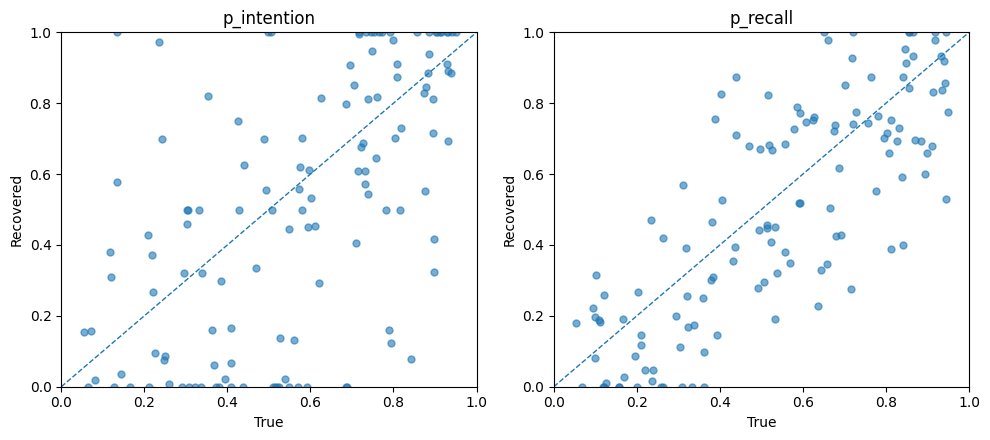

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

pairs = [
    ("true_p_intention", "est_p_intention", "p_intention"),
    ("true_p_recall", "est_p_recall", "p_recall"),
]

for ax, (tcol, ecol, title) in zip(axes.ravel(), pairs):
    ax.scatter(recovery_df[tcol], recovery_df[ecol], alpha=0.6, s=25)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("True")
    ax.set_ylabel("Recovered")
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Boundary-collapse diagnostics

Check how often recovered estimates land near:

- the lower boundary: $< 0.05$
- the upper boundary: $> 0.95$

In [20]:
for col in ["est_p_intention", "est_p_recall"]:
    print(col)
    print("near 0:", (recovery_df[col] < 0.05).sum())
    print("near 1:", (recovery_df[col] > 0.95).sum())
    print()

est_p_intention
near 0: 26
near 1: 23

est_p_recall
near 0: 16
near 1: 10



# Recovery map 

The previous recovery simulation sampled true values randomly across the parameter space.

This section evaluates recovery on a structured 2D grid over:

- $p_{\text{intention}}$
- $p_{\text{recall}}$

At each grid point:

1. fix the true values to that $(p_{\text{intention}}, p_{\text{recall}})$ pair,
2. simulate many synthetic datasets using the **real filtered denominators**,
3. refit the same 2-parameter RecallOverride model,
4. summarize recovery quality.

This gives a direct map of:

- where recovery is stable,
- where recovery is biased or noisy,
- where estimates tend to collapse toward 0 or 1.

## Grid and simulation settings

In [21]:
grid_n = 10
n_reps_per_grid = 30
boundary_low = 0.05
boundary_high = 0.95

p_int_grid = np.linspace(0.05, 0.95, grid_n)
p_rec_grid = np.linspace(0.05, 0.95, grid_n)

print("Grid points for p_intention:", p_int_grid)
print("Grid points for p_recall:", p_rec_grid)
print("Replicates per grid point:", n_reps_per_grid)

Grid points for p_intention: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Grid points for p_recall: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Replicates per grid point: 30


## Simulate and refit at one fixed grid point

For one fixed pair of true values,

$$
(p_{\text{intention}}^{\text{true}},\; p_{\text{recall}}^{\text{true}})
$$

Repeatedly:

1. generate synthetic correct counts from the binomial model,
2. refit the 2-parameter RecallOverride model,
3. store the recovered estimates.

In [22]:
def run_gridpoint_recovery_recalloverride_2param(
    true_p_intention,
    true_p_recall,
    fit_counts,
    p_cue_probe,
    load=1,
    m=1.0,
    p_slip=0.0,
    lambda_=0.0,
    n_reps=30,
    seed=2026
):
    rng = np.random.default_rng(seed)

    true_params = np.array([true_p_intention, true_p_recall], dtype=float)
    recovered = []

    for rep in range(n_reps):
        idx = rng.integers(0, fit_counts.shape[0])
        n_trials = fit_counts[idx].copy()

        true_accs = predict_accuracies_recalloverride_2param(
            true_params,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_
        )

        n_correct = rng.binomial(n_trials, true_accs)

        fit_res = fit_one_participant_recalloverride_2param(
            n_trials=n_trials,
            n_correct=n_correct,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_,
            n_starts=30,
            seed=int(rng.integers(1, 10_000_000))
        )

        est_p_intention, est_p_recall = fit_res["params"]

        recovered.append({
            "true_p_intention": true_p_intention,
            "true_p_recall": true_p_recall,
            "est_p_intention": est_p_intention,
            "est_p_recall": est_p_recall,
            "fit_success": fit_res["success"],
            "nll": fit_res["fun"]
        })

    return pd.DataFrame(recovered)

## Summarize recovery at one grid point

In [23]:
def summarize_gridpoint_recovery_2param(df_grid, low=0.05, high=0.95):
    out = {
        "true_p_intention": df_grid["true_p_intention"].iloc[0],
        "true_p_recall": df_grid["true_p_recall"].iloc[0],
        "n_reps": len(df_grid),
        "fit_success_rate": df_grid["fit_success"].mean(),

        "mean_est_p_intention": df_grid["est_p_intention"].mean(),
        "bias_p_intention": (df_grid["est_p_intention"] - df_grid["true_p_intention"]).mean(),
        "rmse_p_intention": np.sqrt(np.mean((df_grid["est_p_intention"] - df_grid["true_p_intention"])**2)),
        "prop_low_p_intention": (df_grid["est_p_intention"] < low).mean(),
        "prop_high_p_intention": (df_grid["est_p_intention"] > high).mean(),

        "mean_est_p_recall": df_grid["est_p_recall"].mean(),
        "bias_p_recall": (df_grid["est_p_recall"] - df_grid["true_p_recall"]).mean(),
        "rmse_p_recall": np.sqrt(np.mean((df_grid["est_p_recall"] - df_grid["true_p_recall"])**2)),
        "prop_low_p_recall": (df_grid["est_p_recall"] < low).mean(),
        "prop_high_p_recall": (df_grid["est_p_recall"] > high).mean(),
    }
    return out

## Run the full 2D grid recovery map

In [24]:
grid_records = []

total_jobs = len(p_int_grid) * len(p_rec_grid)
job_counter = 0

for true_p_intention in p_int_grid:
    for true_p_recall in p_rec_grid:
        job_counter += 1
        print(f"Running grid point {job_counter}/{total_jobs}: "
              f"p_int={true_p_intention:.2f}, p_rec={true_p_recall:.2f}")

        df_grid = run_gridpoint_recovery_recalloverride_2param(
            true_p_intention=true_p_intention,
            true_p_recall=true_p_recall,
            fit_counts=fit_counts,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_,
            n_reps=n_reps_per_grid,
            seed=2026 + job_counter
        )

        grid_records.append(summarize_gridpoint_recovery_2param(
            df_grid,
            low=boundary_low,
            high=boundary_high
        ))

grid_summary_2p = pd.DataFrame(grid_records)
print("Done.")
grid_summary_2p.head()

Running grid point 1/100: p_int=0.05, p_rec=0.05
Running grid point 2/100: p_int=0.05, p_rec=0.15
Running grid point 3/100: p_int=0.05, p_rec=0.25
Running grid point 4/100: p_int=0.05, p_rec=0.35
Running grid point 5/100: p_int=0.05, p_rec=0.45
Running grid point 6/100: p_int=0.05, p_rec=0.55
Running grid point 7/100: p_int=0.05, p_rec=0.65
Running grid point 8/100: p_int=0.05, p_rec=0.75
Running grid point 9/100: p_int=0.05, p_rec=0.85
Running grid point 10/100: p_int=0.05, p_rec=0.95
Running grid point 11/100: p_int=0.15, p_rec=0.05
Running grid point 12/100: p_int=0.15, p_rec=0.15
Running grid point 13/100: p_int=0.15, p_rec=0.25
Running grid point 14/100: p_int=0.15, p_rec=0.35
Running grid point 15/100: p_int=0.15, p_rec=0.45
Running grid point 16/100: p_int=0.15, p_rec=0.55
Running grid point 17/100: p_int=0.15, p_rec=0.65
Running grid point 18/100: p_int=0.15, p_rec=0.75
Running grid point 19/100: p_int=0.15, p_rec=0.85
Running grid point 20/100: p_int=0.15, p_rec=0.95
Running g

,true_p_intention,true_p_recall,n_reps,fit_success_rate,mean_est_p_intention,bias_p_intention,rmse_p_intention,prop_low_p_intention,prop_high_p_intention,mean_est_p_recall,bias_p_recall,rmse_p_recall,prop_low_p_recall,prop_high_p_recall
0,0.05,0.05,30,1.0,0.046630,-0.003370,0.067610,0.633333,0.0,0.093041,0.043041,0.140023,0.533333,0.0
1,0.05,0.15,30,1.0,0.090455,0.040455,0.123500,0.566667,0.0,0.121628,-0.028372,0.136330,0.433333,0.0
2,0.05,0.25,30,1.0,0.105314,0.055314,0.137243,0.466667,0.0,0.251067,0.001067,0.218629,0.266667,0.0
3,0.05,0.35,30,1.0,0.098696,0.048696,0.119812,0.466667,0.0,0.262057,-0.087943,0.188683,0.100000,0.0
4,0.05,0.45,30,1.0,0.130777,0.080777,0.176408,0.533333,0.0,0.425878,-0.024122,0.179565,0.033333,0.0


## Helper: convert grid summaries into heatmap matrices

In [25]:
def make_heatmap_matrix(df, value_col, p_int_grid, p_rec_grid):
    mat = (
        df.pivot(index="true_p_intention", columns="true_p_recall", values=value_col)
          .reindex(index=p_int_grid, columns=p_rec_grid)
          .to_numpy()
    )
    return mat

## Heatmaps for recovered $p_{\text{intention}}$

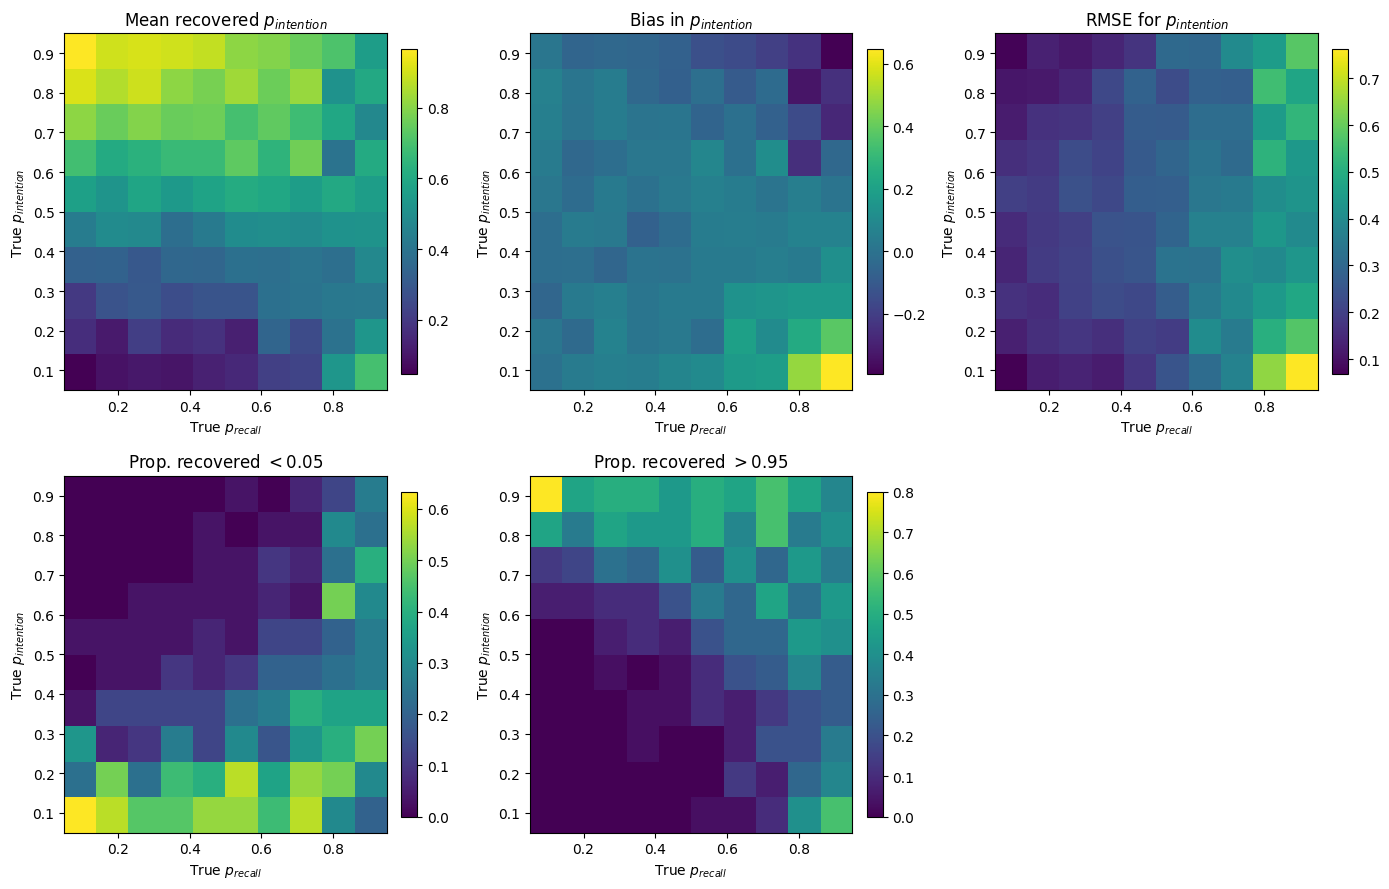

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

metrics_to_plot_int = [
    ("mean_est_p_intention", "Mean recovered $p_{intention}$"),
    ("bias_p_intention", "Bias in $p_{intention}$"),
    ("rmse_p_intention", "RMSE for $p_{intention}$"),
    ("prop_low_p_intention", "Prop. recovered $< 0.05$"),
    ("prop_high_p_intention", "Prop. recovered $> 0.95$"),
]

for ax, (col, title) in zip(axes.ravel(), metrics_to_plot_int):
    mat = make_heatmap_matrix(grid_summary_2p, col, p_int_grid, p_rec_grid)
    im = ax.imshow(
        mat,
        origin="lower",
        aspect="auto",
        extent=[p_rec_grid.min(), p_rec_grid.max(), p_int_grid.min(), p_int_grid.max()]
    )
    ax.set_title(title)
    ax.set_xlabel("True $p_{recall}$")
    ax.set_ylabel("True $p_{intention}$")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

## Heatmaps for recovered $p_{\text{recall}}$

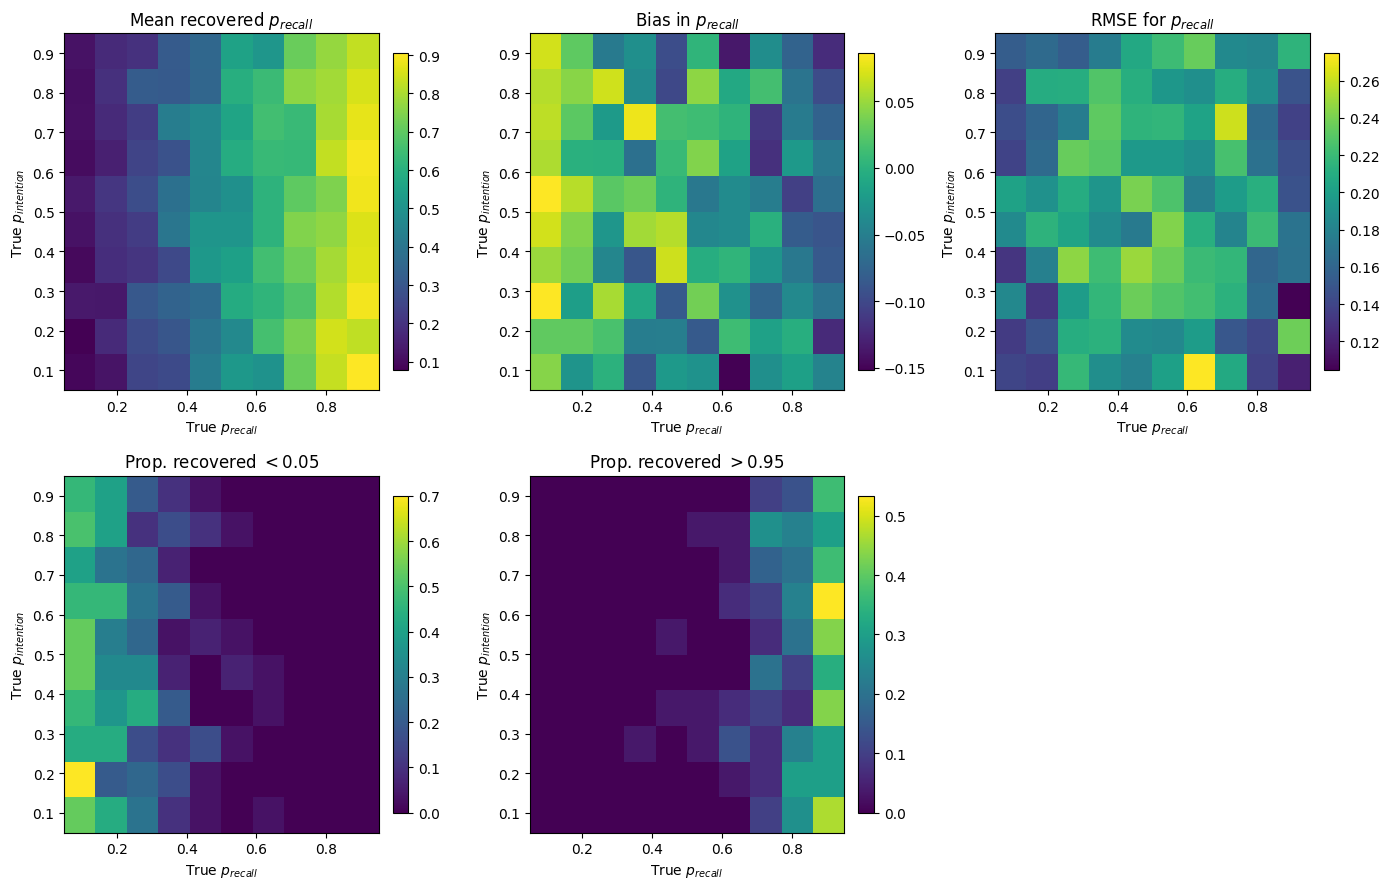

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

metrics_to_plot_rec = [
    ("mean_est_p_recall", "Mean recovered $p_{recall}$"),
    ("bias_p_recall", "Bias in $p_{recall}$"),
    ("rmse_p_recall", "RMSE for $p_{recall}$"),
    ("prop_low_p_recall", "Prop. recovered $< 0.05$"),
    ("prop_high_p_recall", "Prop. recovered $> 0.95$"),
]

for ax, (col, title) in zip(axes.ravel(), metrics_to_plot_rec):
    mat = make_heatmap_matrix(grid_summary_2p, col, p_int_grid, p_rec_grid)
    im = ax.imshow(
        mat,
        origin="lower",
        aspect="auto",
        extent=[p_rec_grid.min(), p_rec_grid.max(), p_int_grid.min(), p_int_grid.max()]
    )
    ax.set_title(title)
    ax.set_xlabel("True $p_{recall}$")
    ax.set_ylabel("True $p_{intention}$")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

## Check recoverability asymmetry 

Summarize whether:

- recovery of $p_{\text{recall}}$ changes systematically across true $p_{\text{intention}}$,
- recovery of $p_{\text{intention}}$ changes systematically across true $p_{\text{recall}}$.

In [28]:
rec_by_int = (
    grid_summary_2p
    .groupby("true_p_intention", as_index=False)[
        ["rmse_p_recall", "bias_p_recall", "prop_low_p_recall", "prop_high_p_recall"]
    ]
    .mean()
)

int_by_rec = (
    grid_summary_2p
    .groupby("true_p_recall", as_index=False)[
        ["rmse_p_intention", "bias_p_intention", "prop_low_p_intention", "prop_high_p_intention"]
    ]
    .mean()
)

### Dependence of recovered $p_{\text{recall}}$ on true $p_{\text{intention}}$

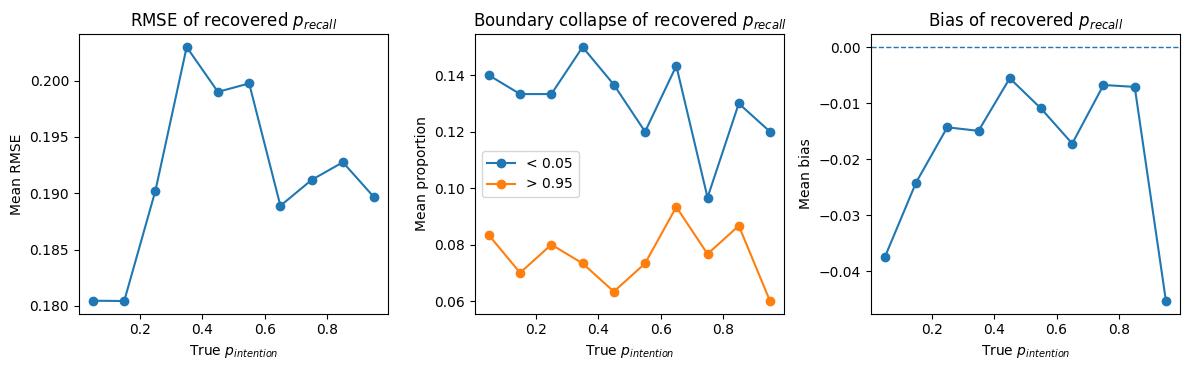

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

axes[0].plot(rec_by_int["true_p_intention"], rec_by_int["rmse_p_recall"], marker="o")
axes[0].set_title("RMSE of recovered $p_{recall}$")
axes[0].set_xlabel("True $p_{intention}$")
axes[0].set_ylabel("Mean RMSE")

axes[1].plot(rec_by_int["true_p_intention"], rec_by_int["prop_low_p_recall"], marker="o", label="< 0.05")
axes[1].plot(rec_by_int["true_p_intention"], rec_by_int["prop_high_p_recall"], marker="o", label="> 0.95")
axes[1].set_title("Boundary collapse of recovered $p_{recall}$")
axes[1].set_xlabel("True $p_{intention}$")
axes[1].set_ylabel("Mean proportion")
axes[1].legend()

axes[2].plot(rec_by_int["true_p_intention"], rec_by_int["bias_p_recall"], marker="o")
axes[2].axhline(0, linestyle="--", linewidth=1)
axes[2].set_title("Bias of recovered $p_{recall}$")
axes[2].set_xlabel("True $p_{intention}$")
axes[2].set_ylabel("Mean bias")

plt.tight_layout()
plt.show()

### Dependence of recovered $p_{\text{intention}}$ on true $p_{\text{recall}}$

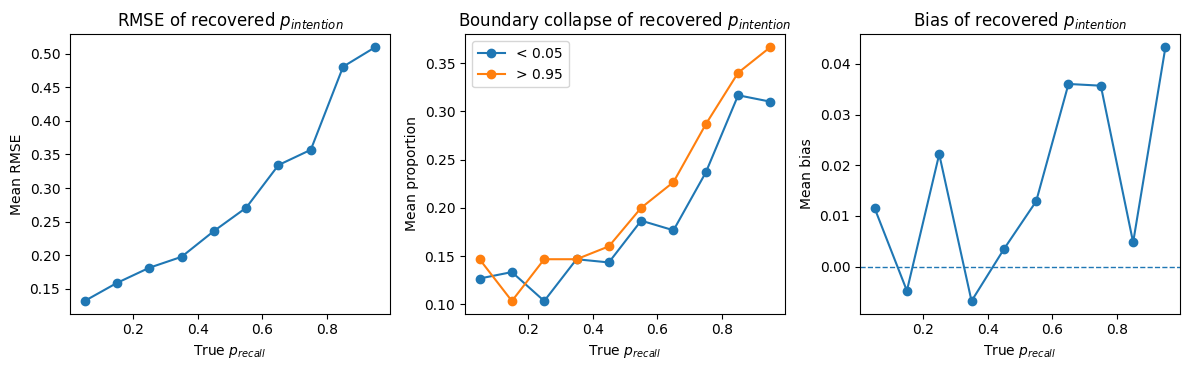

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

axes[0].plot(int_by_rec["true_p_recall"], int_by_rec["rmse_p_intention"], marker="o")
axes[0].set_title("RMSE of recovered $p_{intention}$")
axes[0].set_xlabel("True $p_{recall}$")
axes[0].set_ylabel("Mean RMSE")

axes[1].plot(int_by_rec["true_p_recall"], int_by_rec["prop_low_p_intention"], marker="o", label="< 0.05")
axes[1].plot(int_by_rec["true_p_recall"], int_by_rec["prop_high_p_intention"], marker="o", label="> 0.95")
axes[1].set_title("Boundary collapse of recovered $p_{intention}$")
axes[1].set_xlabel("True $p_{recall}$")
axes[1].set_ylabel("Mean proportion")
axes[1].legend()

axes[2].plot(int_by_rec["true_p_recall"], int_by_rec["bias_p_intention"], marker="o")
axes[2].axhline(0, linestyle="--", linewidth=1)
axes[2].set_title("Bias of recovered $p_{intention}$")
axes[2].set_xlabel("True $p_{recall}$")
axes[2].set_ylabel("Mean bias")

plt.tight_layout()
plt.show()

### Quantitative check

- correlation between true $p_{\text{intention}}$ and RMSE of recovered $p_{\text{recall}}$,
- correlation between true $p_{\text{recall}}$ and RMSE of recovered $p_{\text{intention}}$,
- and the same for boundary-collapse rates.

In [31]:
corr_rec_rmse_vs_int = np.corrcoef(
    rec_by_int["true_p_intention"],
    rec_by_int["rmse_p_recall"]
)[0, 1]

corr_int_rmse_vs_rec = np.corrcoef(
    int_by_rec["true_p_recall"],
    int_by_rec["rmse_p_intention"]
)[0, 1]

corr_rec_boundary_vs_int = np.corrcoef(
    rec_by_int["true_p_intention"],
    rec_by_int["prop_low_p_recall"] + rec_by_int["prop_high_p_recall"]
)[0, 1]

corr_int_boundary_vs_rec = np.corrcoef(
    int_by_rec["true_p_recall"],
    int_by_rec["prop_low_p_intention"] + int_by_rec["prop_high_p_intention"]
)[0, 1]

pd.Series({
    "corr(true p_intention, RMSE of recovered p_recall)": corr_rec_rmse_vs_int,
    "corr(true p_recall, RMSE of recovered p_intention)": corr_int_rmse_vs_rec,
    "corr(true p_intention, boundary rate of recovered p_recall)": corr_rec_boundary_vs_int,
    "corr(true p_recall, boundary rate of recovered p_intention)": corr_int_boundary_vs_rec,
}).round(3)

corr(true p_intention, RMSE of recovered p_recall)             0.321
corr(true p_recall, RMSE of recovered p_intention)             0.970
corr(true p_intention, boundary rate of recovered p_recall)   -0.422
corr(true p_recall, boundary rate of recovered p_intention)    0.931
dtype: float64

## Interpretation

`RecallOverride` model appears to **reverse the recoverability asymmetry** seen under `NoInhibition` model.

- Under **NoInhibition**, recovery of $p_{\text{intention}}$ was relatively stable, while recovery of $p_{\text{recall}}$ worsened as true intention increased.
- Under **RecallOverride**, recovery of $p_{\text{recall}}$ is relatively stable, while recovery of $p_{\text{intention}}$ worsens as true recall increases.

This follows from the model structure:

- in **RecallOverride**, recall acts more globally,
- whereas intention only affects the **non-recall** branch.

So when true recall is high, the non-recall branch is used less often, and the data carry less information about $p_{\text{intention}}$. As a result, intention becomes harder to estimate accurately.

This suggests that the recoverability problem is not simply about the **number of parameters**. It depends on the model’s **conditional structure**:

- in **NoInhibition**, recall is conditional on no intention, so recall becomes harder to recover when intention is high;
- in **RecallOverride**, intention is conditional on no recall, so intention becomes harder to recover when recall is high.

## Next step

Model choice should depend on the primary scientific target:

- if the main target is **intention**, the **NoInhibition** model may be more favorable;
- if the main target is **recall**, the **RecallOverride** model may be more favorable.